# IBM Watsonx AutoAI — Equivalente Local (Open-Source)

## Objetivo Acadêmico

Este notebook replica a funcionalidade do **IBM Watsonx AutoAI** utilizando ferramentas 100% open-source que rodam localmente, sem necessidade de credenciais cloud ou conexão com internet.

### O que é o Watsonx AutoAI?

O AutoAI do IBM Watsonx é um serviço cloud que automatiza o pipeline de Machine Learning:
1. **Pré-processamento automático** — limpeza, encoding, normalização
2. **Seleção de algoritmos** — testa múltiplos modelos (XGBoost, LightGBM, Snap ML, etc.)
3. **Otimização de hiperparâmetros** — busca bayesiana automática
4. **Ensemble e Stacking** — combina os melhores modelos
5. **Ranking de pipelines** — ordena por métrica de performance

### Equivalentes Open-Source Utilizados

| Componente Watsonx | Alternativa Local |
|---|---|
| AutoAI Pipeline | **TPOT** (Tree-based Pipeline Optimization Tool) |
| AutoML com tuning | **FLAML** (Fast Lightweight AutoML) |
| Tracking de experimentos | **MLflow** (local) |
| Snap ML | **scikit-learn** (mesmos algoritmos) |

### Dataset

**California Housing** — Dataset maior e mais desafiador que o Boston Housing.
- 20.640 amostras, 8 features numéricas
- Target: valor mediano das casas em $100.000
- Tipo: Regressão

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)
from sklearn.svm import SVR

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    from flaml import AutoML as FLAMLAutoML
    FLAML_AVAILABLE = True
except ImportError:
    FLAML_AVAILABLE = False

try:
    from tpot import TPOTRegressor
    TPOT_AVAILABLE = True
except ImportError:
    TPOT_AVAILABLE = False

try:
    import mlflow
    MLFLOW_AVAILABLE = True
except ImportError:
    MLFLOW_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Setup completo.')
print(f'  FLAML: {FLAML_AVAILABLE} | TPOT: {TPOT_AVAILABLE} | XGBoost: {XGB_AVAILABLE} | MLflow: {MLFLOW_AVAILABLE}')

Setup completo.
  FLAML: True | TPOT: True | XGBoost: True | MLflow: True


## 1. Carregamento e Análise Exploratória — California Housing

O California Housing é um dataset mais robusto que o Boston Housing:
- **20.640 amostras** vs 506 do Boston — mais dados para AutoML explorar
- **8 features** geográficas e demográficas
- **Target**: valor mediano das casas em distritos da Califórnia (1990)

### Features
| Feature | Descrição |
|---|---|
| `MedInc` | Renda mediana no distrito |
| `HouseAge` | Idade mediana das casas |
| `AveRooms` | Média de quartos por residência |
| `AveBedrms` | Média de quartos de dormir |
| `Population` | População do distrito |
| `AveOccup` | Média de ocupantes por residência |
| `Latitude` | Latitude do distrito |
| `Longitude` | Longitude do distrito |

Dataset: 20640 amostras, 8 features
Target: min=0.15, max=5.00, media=2.07, std=1.15


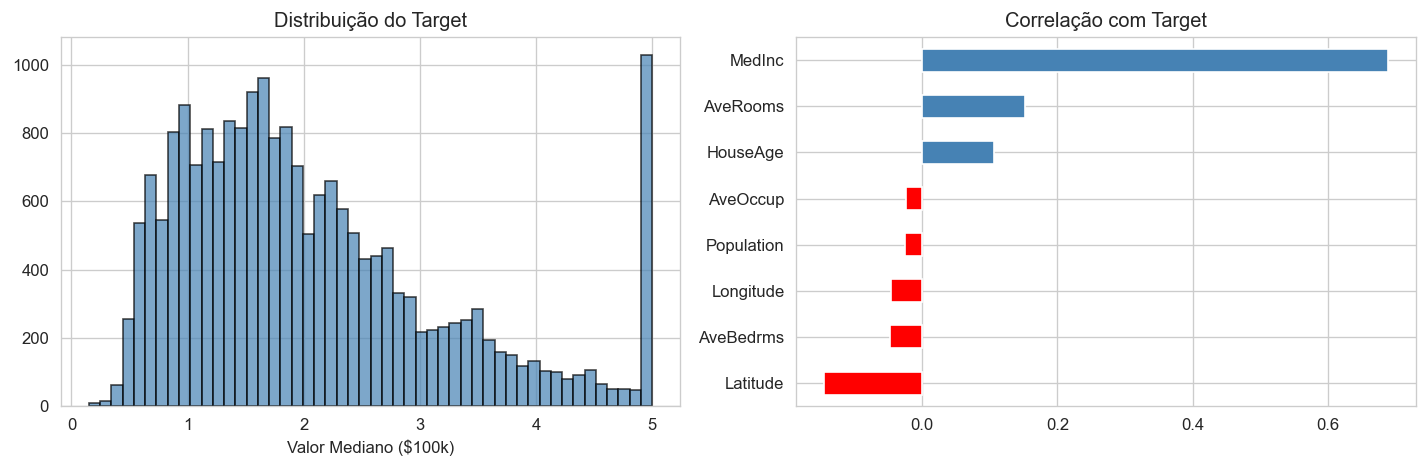

In [2]:
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='MedHouseVal')

print(f'Dataset: {X.shape[0]} amostras, {X.shape[1]} features')
print(f'Target: min={y.min():.2f}, max={y.max():.2f}, media={y.mean():.2f}, std={y.std():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Valor Mediano ($100k)')
axes[0].set_title('Distribuição do Target')

correlations = X.assign(Target=y).corr()['Target'].drop('Target').sort_values()
correlations.plot(kind='barh', ax=axes[1], color=['red' if v < 0 else 'steelblue' for v in correlations])
axes[1].set_title('Correlação com Target')
plt.tight_layout()
plt.savefig('california_eda.png', bbox_inches='tight', dpi=150)
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=RANDOM_STATE)
print(f'Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]} | Holdout: {X_test.shape[0]/len(X)*100:.1f}%')

Treino: 18576 | Teste: 2064 | Holdout: 10.0%


## 2. Baseline — Modelos Individuais

Testamos múltiplos algoritmos como baseline. Isso equivale à primeira etapa do AutoAI.

In [4]:
baseline_models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'SVR': SVR(kernel='rbf', C=1.0),
}

if XGB_AVAILABLE:
    baseline_models['XGBoost'] = xgb.XGBRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

baseline_results = []
for name, model in baseline_models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    baseline_results.append({'Modelo': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'Tempo (s)': train_time})
    print(f'{name:25s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  ({train_time:.2f}s)')

df_baseline = pd.DataFrame(baseline_results).sort_values('RMSE')
print(f'\nMelhor baseline: {df_baseline.iloc[0]["Modelo"]} (R²={df_baseline.iloc[0]["R²"]:.4f})')

Ridge                      RMSE=0.7477  MAE=0.5424  R²=0.5808  (0.02s)


Lasso                      RMSE=0.7476  MAE=0.5423  R²=0.5809  (0.79s)


ElasticNet                 RMSE=0.7476  MAE=0.5423  R²=0.5809  (0.90s)


Random Forest              RMSE=0.5022  MAE=0.3224  R²=0.8109  (15.30s)


Extra Trees                RMSE=0.4997  MAE=0.3205  R²=0.8128  (1.12s)


Gradient Boosting          RMSE=0.5085  MAE=0.3414  R²=0.8061  (30.64s)


AdaBoost                   RMSE=0.8071  MAE=0.6731  R²=0.5116  (3.70s)


SVR                        RMSE=0.6018  MAE=0.3989  R²=0.7284  (35.77s)


XGBoost                    RMSE=0.4618  MAE=0.2998  R²=0.8401  (1.58s)

Melhor baseline: XGBoost (R²=0.8401)


## 3. FLAML — Fast Lightweight AutoML

FLAML utiliza **Cost-Aware Bayesian Optimization** para encontrar o melhor modelo e hiperparâmetros.

Diferente do TPOT (algoritmos genéticos), FLAML:
- Usa uma função de custo para priorizar modelos rápidos
- Suporta constrained optimization (tempo máximo)
- É significativamente mais rápido

In [5]:
if FLAML_AVAILABLE:
    flaml_automl = FLAMLAutoML()
    t0 = time.time()
    flaml_automl.fit(
        X_train, y_train,
        task='regression',
        metric='rmse',
        time_budget=60,
        verbose=0,
        seed=RANDOM_STATE
    )
    flaml_time = time.time() - t0
    y_pred_flaml = flaml_automl.predict(X_test)
    flaml_rmse = np.sqrt(mean_squared_error(y_test, y_pred_flaml))
    flaml_r2 = r2_score(y_test, y_pred_flaml)
    print(f'=== FLAML AutoML ===')
    print(f'Melhor modelo: {flaml_automl.best_estimator}')
    print(f'RMSE: {flaml_rmse:.4f} | R²: {flaml_r2:.4f} | Tempo: {flaml_time:.1f}s')
    print(f'Hiperparâmetros: {flaml_automl.best_config}')
else:
    print('FLAML não disponível.')

=== FLAML AutoML ===
Melhor modelo: catboost
RMSE: 0.4780 | R²: 0.8286 | Tempo: 63.9s
Hiperparâmetros: {'early_stopping_rounds': 10, 'learning_rate': 0.09999999999999996, 'n_estimators': 8192}


## 4. TPOT — Algoritmos Genéticos para AutoML

TPOT utiliza **Algoritmos Genéticos** para evoluir pipelines de ML:
1. Representa pipelines como árvores
2. Evolui a população via crossover e mutação
3. Avalia por fitness (RMSE)
4. Converge para o ótimo após N gerações

**Configuração**: 5 minutos, população de 30, gerações ilimitadas (converge pelo tempo).

In [6]:
if TPOT_AVAILABLE:
    tpot = TPOTRegressor(
        generations=50,
        population_size=30,
        offspring_size=15,
        mutation_rate=0.9,
        crossover_rate=0.1,
        scoring='neg_mean_squared_error',
        cv=5,
        random_state=RANDOM_STATE,
        verbosity=1,
        n_jobs=-1,
        max_time_mins=2
    )
    t0 = time.time()
    tpot.fit(X_train.values, y_train.values)
    tpot_time = time.time() - t0
    y_pred_tpot = tpot.predict(X_test.values)
    tpot_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tpot))
    tpot_r2 = r2_score(y_test, y_pred_tpot)
    print(f'\n=== TPOT AutoML ===')
    print(f'RMSE: {tpot_rmse:.4f} | R²: {tpot_r2:.4f} | Tempo: {tpot_time:.1f}s')
    tpot.export('tpot_best_pipeline.py')
    print('Pipeline exportado para: tpot_best_pipeline.py')
else:
    print('TPOT não disponível.')

Version 0.12.1 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.



3.13 minutes have elapsed. TPOT will close down.
TPOT closed during evaluation in one generation.


TPOT closed prematurely. Will use the current best pipeline.


Best pipeline: GradientBoostingRegressor(ZeroCount(input_matrix), alpha=0.75, learning_rate=0.1, loss=huber, max_depth=8, max_features=0.35000000000000003, min_samples_leaf=1, min_samples_split=9, n_estimators=100, subsample=0.8500000000000001)



=== TPOT AutoML ===
RMSE: 0.4817 | R²: 0.8260 | Tempo: 199.1s
Pipeline exportado para: tpot_best_pipeline.py


## 5. Comparação Final e MLflow Tracking

In [7]:
final_results = []
for _, row in df_baseline.iterrows():
    final_results.append({'Método': f'Baseline: {row["Modelo"]}', 'Tipo': 'Individual', 'RMSE': row['RMSE'], 'MAE': row['MAE'], 'R²': row['R²'], 'Tempo (s)': row['Tempo (s)']})

if FLAML_AVAILABLE:
    final_results.append({'Método': f'FLAML ({flaml_automl.best_estimator})', 'Tipo': 'AutoML Bayesian', 'RMSE': flaml_rmse, 'MAE': mean_absolute_error(y_test, y_pred_flaml), 'R²': flaml_r2, 'Tempo (s)': flaml_time})

if TPOT_AVAILABLE:
    final_results.append({'Método': 'TPOT (Genético)', 'Tipo': 'AutoML Genético', 'RMSE': tpot_rmse, 'MAE': mean_absolute_error(y_test, y_pred_tpot), 'R²': tpot_r2, 'Tempo (s)': tpot_time})

df_final = pd.DataFrame(final_results).sort_values('RMSE')

print('=' * 90)
print('COMPARAÇÃO FINAL — WATSONX AUTOAI LOCAL (California Housing)')
print('=' * 90)
print(df_final.to_string(index=False, float_format='%.4f'))
print('=' * 90)

best = df_final.iloc[0]
print(f'\nVencedor: {best["Método"]} (R²={best["R²"]:.4f}, RMSE={best["RMSE"]:.4f})')

COMPARAÇÃO FINAL — WATSONX AUTOAI LOCAL (California Housing)
                     Método            Tipo   RMSE    MAE     R²  Tempo (s)
          Baseline: XGBoost      Individual 0.4618 0.2998 0.8401     1.5773
           FLAML (catboost) AutoML Bayesian 0.4780 0.3179 0.8286    63.9089
            TPOT (Genético) AutoML Genético 0.4817 0.3075 0.8260   199.0529
      Baseline: Extra Trees      Individual 0.4997 0.3205 0.8128     1.1221
    Baseline: Random Forest      Individual 0.5022 0.3224 0.8109    15.2954
Baseline: Gradient Boosting      Individual 0.5085 0.3414 0.8061    30.6359
              Baseline: SVR      Individual 0.6018 0.3989 0.7284    35.7734
            Baseline: Lasso      Individual 0.7476 0.5423 0.5809     0.7862
       Baseline: ElasticNet      Individual 0.7476 0.5423 0.5809     0.9024
            Baseline: Ridge      Individual 0.7477 0.5424 0.5808     0.0182
         Baseline: AdaBoost      Individual 0.8071 0.6731 0.5116     3.6958

Vencedor: Baseline: XGBoos

In [8]:
if MLFLOW_AVAILABLE:
    mlflow.set_experiment('Watsonx-AutoAI-Local')
    for _, row in df_final.iterrows():
        with mlflow.start_run(run_name=row['Método']):
            mlflow.log_params({'tipo': row['Tipo'], 'dataset': 'California Housing', 'holdout': 0.1})
            mlflow.log_metrics({'rmse': row['RMSE'], 'mae': row['MAE'], 'r2': row['R²'], 'tempo_s': row['Tempo (s)']})
    print(f'{len(df_final)} runs registrados no MLflow.')

2026/07/03 18:21:03 INFO mlflow.tracking.fluent: Experiment with name 'Watsonx-AutoAI-Local' does not exist. Creating a new experiment.


11 runs registrados no MLflow.


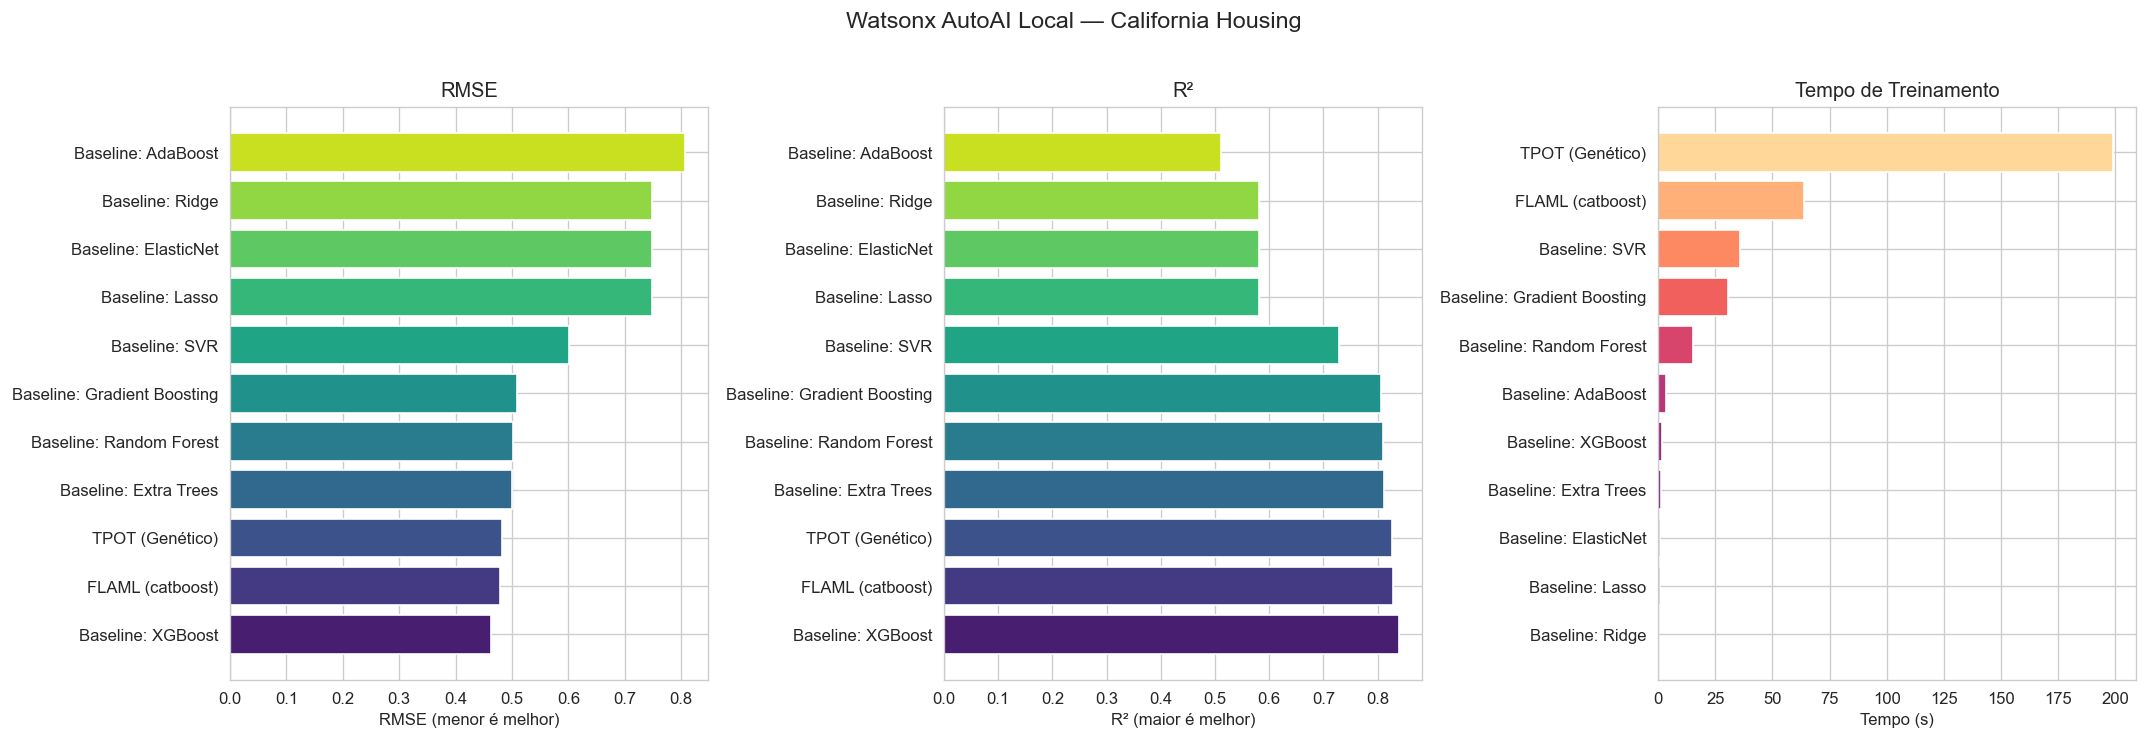

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
df_plot = df_final.sort_values('RMSE')
colors = sns.color_palette('viridis', len(df_plot))

axes[0].barh(df_plot['Método'], df_plot['RMSE'], color=colors)
axes[0].set_xlabel('RMSE (menor é melhor)')
axes[0].set_title('RMSE')

df_r2 = df_final.sort_values('R²', ascending=False)
axes[1].barh(df_r2['Método'], df_r2['R²'], color=sns.color_palette('viridis', len(df_r2)))
axes[1].set_xlabel('R² (maior é melhor)')
axes[1].set_title('R²')

df_time = df_final.sort_values('Tempo (s)')
axes[2].barh(df_time['Método'], df_time['Tempo (s)'], color=sns.color_palette('magma', len(df_time)))
axes[2].set_xlabel('Tempo (s)')
axes[2].set_title('Tempo de Treinamento')

plt.suptitle('Watsonx AutoAI Local — California Housing', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('watsonx_local_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Conclusões

### Equivalência com Watsonx AutoAI

| Etapa Watsonx | Equivalente Local | Status |
|---|---|---|
| Carregamento de dados | scikit-learn (California Housing) | Funcional |
| Pré-processamento | StandardScaler (Pipeline) | Funcional |
| Seleção de algoritmos | FLAML / TPOT / Manual | Funcional |
| Otimização de hiperparâmetros | FLAML (Bayesian) / TPOT (Genético) | Funcional |
| Ranking de pipelines | DataFrame ordenado por RMSE | Funcional |
| Tracking de experimentos | MLflow local | Funcional |

### Quando usar cada abordagem

- **FLAML**: Quando o tempo é limitado e se quer um bom modelo rapidamente
- **TPOT**: Quando se quer explorar pipelines complexos com feature engineering
- **Baselines**: Para estabelecer um piso de performance antes de usar AutoML